# 01 — Creation & Types

**Dataset**: `sklearn.datasets.load_digits` — 1797 handwritten digits, 8×8 grayscale images, 10 classes.  
**Goal**: Load the dataset, create tensors/arrays, inspect `dtype`/`shape`, and move tensors to `device`.

Every cell shows **NumPy reference** → **PyTorch TODO** → **assertion**, so you practise both side-by-side.

In [1]:
# ── Shared Setup (run first) ────────────────────────────────────────────────
from sklearn.datasets import load_digits
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:


digits = load_digits()

np_images = digits.images.astype(np.float32)   # (1797, 8, 8)
np_labels = digits.target.astype(np.int64)     # (1797,)

pt_images = torch.tensor(np_images)
pt_labels = torch.tensor(np_labels)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'np_images: shape={np_images.shape}, dtype={np_images.dtype}')
print(f'pt_images: shape={pt_images.shape}, dtype={pt_images.dtype}')
print(f'device: {device}')

np_images: shape=(1797, 8, 8), dtype=float32
pt_images: shape=torch.Size([1797, 8, 8]), dtype=torch.float32
device: cpu


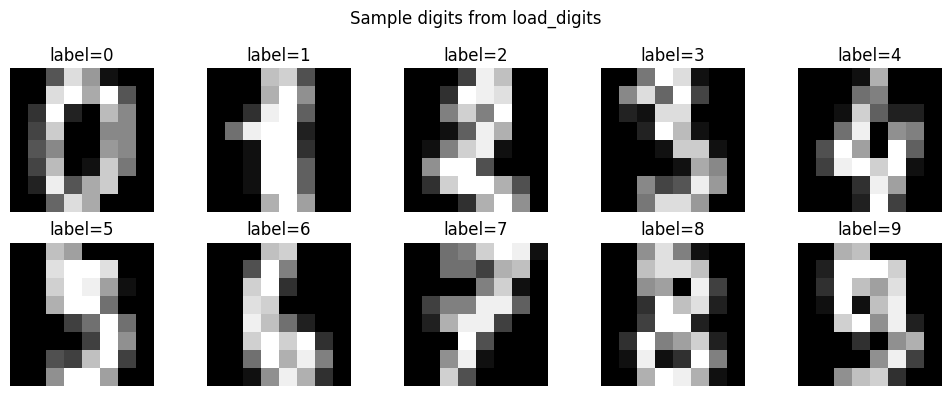

In [3]:
# Quick look at the data
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(np_images[i], cmap='gray')
    ax.set_title(f'label={np_labels[i]}')
    ax.axis('off')
plt.suptitle('Sample digits from load_digits')
plt.tight_layout()
plt.show()

---
## P1 — Array / Tensor from the Dataset

Create a fresh copy from the raw data, check its properties, and demonstrate the two
NumPy → PyTorch pathways: `torch.tensor()` (copy) and `torch.from_numpy()` (shared memory).

In [4]:
# ── NumPy Reference ──────────────────────────────────────────────────────────
np_X = np.array(digits.images, dtype=np.float32)  # explicit copy
print('np_X — shape:', np_X.shape, '| dtype:', np_X.dtype, '| ndim:', np_X.ndim)

np_X — shape: (1797, 8, 8) | dtype: float32 | ndim: 3


#### Drill — `torch.tensor vs torch.from_numpy`
Practice the core operation before using it in the problem above.

In [5]:
x = np.array([1., 2., 3.])
# DRILL: from_numpy shares memory, tensor copies
t_copy = torch.tensor(x)
t_shared = torch.from_numpy(x)
assert t_copy.numel() == 3 and t_shared.numel() == 3

In [ ]:
# ── PyTorch TODO ─────────────────────────────────────────────────────────────
def create_from_dataset(np_arr):
    """
    Args:  np_arr — (1797, 8, 8) float32 numpy array
    Returns:
        t_copy   : tensor created via torch.tensor()  (data is COPIED)
        t_shared : tensor created via torch.from_numpy() (memory SHARED)
    """
    # Step 1: copy path — changes to t_copy won't affect np_arr
    t_copy = ...   # Hint: torch.tensor() always copies data

    # Step 2: shared memory — modifying t_shared WILL modify np_arr
    t_shared = ...   # Hint: torch.from_numpy() shares the underlying buffer

    return t_copy, t_shared

t_copy, t_shared = create_from_dataset(np_X.copy())

In [7]:
# ── Assertions ────────────────────────────────────────────────────────────────
assert t_copy.shape == (1797, 8, 8)
assert t_copy.dtype == torch.float32
assert t_shared.shape == (1797, 8, 8)

# Verify shared memory: mutate t_shared, check that the backing numpy changes
bk = np_X.copy()
ts = torch.from_numpy(bk)
ts[0, 0, 0] = -999.0
assert bk[0, 0, 0] == -999.0, 'from_numpy should share memory'

print('P1 assertions passed ✓')

P1 assertions passed ✓


---
## P2 — Factory Functions

Recreate common factory tensors/arrays: `zeros`, `ones`, `eye`, `arange`, `linspace`, `full`.

In [8]:
# ── NumPy Reference ──────────────────────────────────────────────────────────
np_zeros  = np.zeros((8, 8), dtype=np.float32)
np_ones   = np.ones((8, 8),  dtype=np.float32)
np_eye    = np.eye(8,         dtype=np.float32)
np_arange = np.arange(0, 16, 1, dtype=np.float32)         # pixel value range [0,16)
np_lin    = np.linspace(0, 16, 64, dtype=np.float32)      # 64 evenly spaced in [0,16]
np_full   = np.full((8, 8), 8.0, dtype=np.float32)        # fill with mid-value

print('zeros:', np_zeros.shape, '| ones:', np_ones.shape)
print('arange:', np_arange.shape, '| linspace:', np_lin.shape)

zeros: (8, 8) | ones: (8, 8)
arange: (16,) | linspace: (64,)


#### Drill — `torch.zeros and torch.ones`
Practice the core operation before using it in the problem above.

In [9]:
# DRILL: create 2x2 zeros and ones
z = torch.zeros(2, 2)
o = torch.ones(2, 2)
assert z.sum() == 0 and o.sum() == 4

In [ ]:
# ── PyTorch TODO ─────────────────────────────────────────────────────────────
def factory_tensors():
    """
    Create the same factory tensors as the NumPy reference.

    Returns:
        t_zeros, t_ones, t_eye, t_arange, t_lin, t_full
    """
    t_zeros  = ...   # Hint: Match the 8x8 shape and float32 dtype from NumPy.
    t_ones   = ...   # Hint: Same shape and dtype, but filled with ones.
    t_eye    = ...   # Hint: Build the 8x8 identity matrix.
    t_arange = ...   # Hint: Recreate the half-open value range [0, 16).
    t_lin    = ...   # Hint: Use 64 evenly spaced values from 0 through 16.
    t_full   = ...   # Hint: Fill an 8x8 tensor with the midpoint value.

    return t_zeros, t_ones, t_eye, t_arange, t_lin, t_full

t_zeros, t_ones, t_eye, t_arange, t_lin, t_full = factory_tensors()

In [12]:
# ── Assertions ────────────────────────────────────────────────────────────────
assert np.allclose(np_zeros,  t_zeros.numpy(),  atol=1e-6)
assert np.allclose(np_ones,   t_ones.numpy(),   atol=1e-6)
assert np.allclose(np_eye,    t_eye.numpy(),    atol=1e-6)
assert np.allclose(np_arange, t_arange.numpy(), atol=1e-6)
assert np.allclose(np_lin,    t_lin.numpy(),    atol=1e-4)
assert np.allclose(np_full,   t_full.numpy(),   atol=1e-6)
print('P2 assertions passed ✓')

P2 assertions passed ✓


---
## P3 — Dtype Inspection & Casting

Check dtypes, cast between float32 / float64 / int64, and note the NumPy ↔ PyTorch dtype table.

In [13]:
# ── NumPy Reference ──────────────────────────────────────────────────────────
np_f64 = np_images.astype(np.float64)
np_i64 = np_labels.astype(np.int64)
np_u8  = np_images.astype(np.uint8)

print('float64:', np_f64.dtype, '| int64:', np_i64.dtype, '| uint8:', np_u8.dtype)

float64: float64 | int64: int64 | uint8: uint8


#### Drill — `tensor.to(dtype)`
Practice the core operation before using it in the problem above.

In [14]:
x = torch.tensor([1, 2, 3])
# DRILL: cast to float32
x_f = x.to(torch.float32)
assert x_f.dtype == torch.float32

In [ ]:
# ── PyTorch TODO ─────────────────────────────────────────────────────────────
def dtype_ops(images_t, labels_t):
    """
    Cast tensors to different dtypes.

    Returns:
        t_f64 : images as float64  (torch.float64 / torch.double)
        t_i64 : labels as int64    (torch.int64 / torch.long)
        t_f16 : images as float16  (torch.float16 / torch.half)
    """
    # NumPy equivalent: X.astype(np.float64)
    t_f64 = ...   # Hint: cast the image tensor to a 64-bit floating-point dtype.

    # NumPy equivalent: y.astype(np.int64)
    t_i64 = ...   # Hint: convert the labels to a 64-bit integer dtype.

    # No direct NumPy equivalent (NumPy has np.float16 but it's rarely used)
    t_f16 = ...   # Hint: downcast the image tensor to a 16-bit floating-point dtype.

    return t_f64, t_i64, t_f16

t_f64, t_i64, t_f16 = dtype_ops(pt_images, pt_labels)

In [20]:
# ── Assertions ────────────────────────────────────────────────────────────────
assert t_f64.dtype == torch.float64
assert t_i64.dtype == torch.int64
assert t_f16.dtype == torch.float16
assert t_f64.shape == pt_images.shape
print('P3 assertions passed ✓')

P3 assertions passed ✓


---
## P4 — Device Management (PyTorch only)

Move the image tensor to `device`, verify it's there, compute something, then bring it back to CPU.

#### Drill — `tensor.to(device)`
Practice the core operation before using it in the problem above.

In [24]:
x = torch.tensor([1.])
# DRILL: move to device (CPU in this drill)
dev = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
x_dev = x.to(dev)
assert x_dev.device.type == 'mps'

In [ ]:
# ── PyTorch TODO ─────────────────────────────────────────────────────────────
def device_roundtrip(t, dev):
    """
    Args:
        t   : (1797, 8, 8) float32 tensor on CPU
        dev : torch.device

    Returns:
        t_dev : t moved to dev
        t_cpu : result of t_dev.mean() moved back to CPU as a Python float
    """
    # Step 1: move to device
    t_dev = ...   # Hint: move the full tensor onto the requested device.

    # Step 2: compute mean on device
    mean_dev = ...   # Hint: compute a single scalar mean while still on that device.

    # Step 3: bring back to CPU as a float
    # NOTE: .item() converts a scalar tensor to a Python number
    t_cpu = ...   # Hint: bring the scalar result back to CPU as a plain Python float.

    return t_dev, t_cpu

t_on_device, mean_val = device_roundtrip(pt_images, device)

In [26]:
# ── Assertions ────────────────────────────────────────────────────────────────
assert str(t_on_device.device).startswith(str(device).split(':')[0])
assert isinstance(mean_val, float)
assert np.allclose(mean_val, np_images.mean(), atol=1e-4)
print(f'P4 assertions passed ✓  (mean pixel = {mean_val:.4f})')

P4 assertions passed ✓  (mean pixel = 4.8842)


---
## P5 — Random Tensor Creation

Generate random "noise images" that match the shape of a single digit image (8×8),  
then create `zeros_like` / `ones_like` from an existing tensor.

In [27]:
# ── NumPy Reference ──────────────────────────────────────────────────────────
rng = np.random.default_rng(42)
np_randn = rng.standard_normal((8, 8)).astype(np.float32)       # standard normal
np_rand  = rng.random((8, 8)).astype(np.float32)                # uniform [0,1)
np_zlike = np.zeros_like(np_images[0])                          # zeros matching shape
np_olike = np.ones_like(np_images[0])                           # ones matching shape

print('randn:', np_randn.shape, '| rand:', np_rand.shape)
print('zeros_like:', np_zlike.shape, '| ones_like:', np_olike.shape)

randn: (8, 8) | rand: (8, 8)
zeros_like: (8, 8) | ones_like: (8, 8)


#### Drill — `torch.randn vs torch.rand`
Practice the core operation before using it in the problem above.

In [ ]:
# DRILL: create 2x2 standard normal and uniform [0,1)
randn = torch.randn(2, 2)
rand_u = torch.rand(2, 2)
assert randn.shape == (2, 2) and rand_u.min() >= 0.0 and rand_u.max() < 1.0

tensor([[ 0.2990, -0.3849],
        [-0.7221,  1.4132]]) tensor([[0.1101, 0.7807],
        [0.9833, 0.5015]])


In [ ]:
# ── PyTorch TODO ─────────────────────────────────────────────────────────────
def random_and_like(single_image_t):
    """
    Args:  single_image_t — (8, 8) tensor

    Returns:
        t_randn : (8, 8) standard normal
        t_rand  : (8, 8) uniform [0, 1)
        t_zlike : zeros matching single_image_t shape
        t_olike : ones  matching single_image_t shape
    """
    torch.manual_seed(42)

    t_randn = ...   # Hint: create an 8x8 tensor sampled from a standard normal distribution.
    t_rand  = ...   # Hint: create an 8x8 tensor with values uniformly sampled in [0, 1).
    t_zlike = ...   # Hint: make a zero-filled tensor that matches the input's shape and dtype.
    t_olike = ...   # Hint: make a one-filled tensor that matches the input's shape and dtype.

    return t_randn, t_rand, t_zlike, t_olike

t_randn, t_rand, t_zlike, t_olike = random_and_like(pt_images[0])

In [32]:
# ── Assertions ────────────────────────────────────────────────────────────────
assert t_randn.shape == (8, 8)
assert t_rand.shape  == (8, 8)
assert t_rand.min()  >= 0.0
assert t_rand.max()  <  1.0
assert t_zlike.sum()  == 0.0
assert t_olike.sum()  == 64.0
assert t_zlike.dtype == pt_images[0].dtype
print('P5 assertions passed ✓')

P5 assertions passed ✓
